# 1D AMT Synthetic Inversions (Halfspace + Layered + Position Change)

In [1]:
#Imports

import numpy as np
from simpeg.electromagnetics import natural_source as nsem
from simpeg import maps
import matplotlib.pyplot as plt
import matplotlib
from simpeg.utils import plot_1d_layer_model
from discretize import TensorMesh
import warnings
warnings.filterwarnings("ignore")
from simpeg import (
    maps, data, data_misfit, regularization,
    optimization, inverse_problem, inversion, directives,utils,
)
from ipywidgets import widgets, interact
from pathlib import Path
from mtpy.core.mt_collection import MTCollection
mtc = MTCollection()
import mtpy as mt
import utm
import matplotlib.gridspec as gridspec
import scipy
import pandas as pd


#Solver for Mac
from pymatsolver import Mumps

matplotlib.rcParams['font.size'] = 14

### Reading Synthetic Data Files From Forward Model

In [2]:
dobs = np.load("Forward_Data/Observed_Forward_Model_Data_Original.npy")
dpred = np.load("Forward_Data/Observed_Forward_Model_Data_Reshaped.npy")

### Defining Halfspace Mesh + Starting Model + Map

In [3]:
# Defining Mesh for Halfspace
layer_thick_halfspace = [1000]
n_layers_halfspace = 1
rho = 500

# Defining the mapping
conductivity_halfspace_map = maps.ExpMap(nP=n_layers_halfspace)

m0 = np.log(1/500) * np.ones(n_layers_halfspace)

# Reference model, same as starting 
reference_conductivity_model = m0.copy()


### Bringing in used Frequencies and Geological Details

In [4]:
#Geological properties
layer_thicknesses = np.array([25, 180, 85, 125, 65,70,500]) #Thicknesses were obtained from Tuncer, pg. 16
sigma = 1/np.r_[2000.,2500., 4000., 4500.,8000,500,10000]# in S/m # Unknown resistivities/Conductivities had to be inferred Tuncer Fig. 3-17 borehole data
#sigma = 1/np.r_[500.,500., 500., 500.,500,500,500]# in S/m # Unknown resistivities/Conductivities had to be inferred Tuncer Fig. 3-17 borehole data

#Survey Properties
frequencies = np.r_[7.68*10**3, 5.12*10**3, 3.84*10**3, 1.28*10**3,
    9.59*10**2, 6.4*10**2, 4.64*10**2, 3.36*10**2, 2.4*10**2, 1.77*10**2, 1.28*10**2,
    9.699*10**1,8.1*10**1,7.1*10**1,6.1*10**1,5.1*10**1,4.1*10**1,3.275*10**1,2.225*10**1,1.512*10**1,1.025*10**1,
    6.937,4.875]  # frequencies in Hz # Obtained from Cameco Data, Line 304


### Setting up Simulation

In [5]:
#Setting up RX locations 
rx_loc_single = np.array([[0]])

#Receivers list
receivers_list = [
    nsem.receivers.Impedance(rx_loc_single, orientation="xy", component="real"),  #Only off diagonal components for 1D
    nsem.receivers.Impedance(rx_loc_single, orientation="xy", component="imag"),

    nsem.receivers.Impedance(rx_loc_single, orientation="yx", component="real"),
    nsem.receivers.Impedance(rx_loc_single, orientation="yx", component="imag"),
]

source_list = []
for freq in frequencies:
    source_list.append(nsem.sources.Planewave(receivers_list, freq)) # Setting sources as plane waves at each specified frequencies 

survey = nsem.survey.Survey(source_list) #Creating survey object with given sources form source_list

simulation_hsp = nsem.simulation_1d.Simulation1DRecursive(
        survey=survey,
        sigma = 1/rho,
        thicknesses=[],
        sigmaMap=conductivity_halfspace_map
    )

# ### Using this, I get: NotImplementedError: The getJ method hasn't been implemented for the Simulation1DElectricField yet.
# simulation_hsp = nsem.Simulation1DElectricField(mesh,
#     survey=survey, 
#     sigmaMap=conductivity_halfspace_map,
#     solver = Mumps)


### This error is probably being thrown due to the use of update_jacobi in the directives list below

### Viewing Data

`dobs_new` is created because the forward model simulation and the inversion simulation objects are different. They both take the data differently. Here we are setting it up for the `Simulation1DRecursive` simulation object and then viewing it.

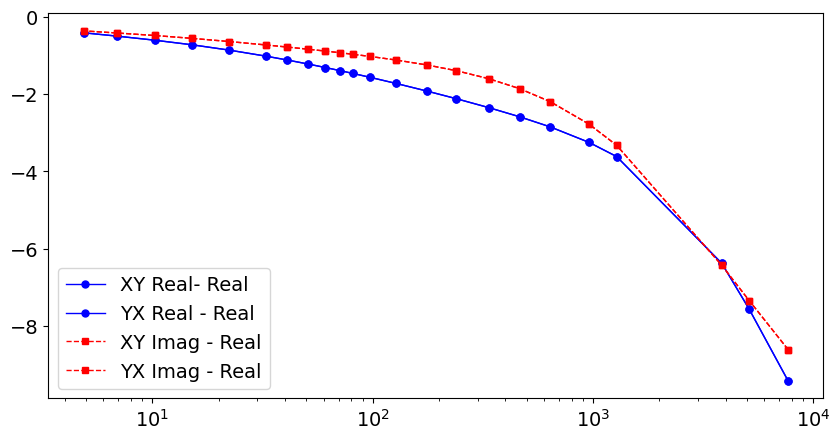

In [6]:
dobs_new = [dpred[:,0] , dpred[:,1], dpred[:,2]*-1 ,  dpred[:,3] * -1 ] # Putting the xy and yx components into a list
dobs_new = np.array(dobs_new) # turning it to a numpy array
dobs_new = dobs_new.flatten(order = 'F') #Flattening it per column instead of per row


real_data_new = dobs_new.reshape(len(frequencies),4) # Reshaping to 23 rows and 4 columns

fig, ax = plt.subplots(1,1,figsize=(10, 5))

#Plotting Real Component XY and YX 
ax.semilogx(frequencies, real_data_new[:,0], "b-o", lw=1, ms=5, label = 'XY Real- Real')
ax.semilogx(frequencies, real_data_new[:,2], "b-o", lw=1, ms=5, label = 'YX Real - Real')

#Pting Imag Component XY and YX 
ax.semilogx(frequencies, real_data_new[:,1], "r--s", lw=1, ms=5, label = 'XY Imag - Real')
ax.semilogx(frequencies, real_data_new[:,3], "r--s", lw=1, ms=5, label = 'YX Imag - Real')

plt.legend()

plt.show()

### Data Misfit

In [7]:
#uncertainties = 0.05 * np.abs(dobs) * np.ones(np.shape(dobs))
data_object = data.Data(survey,
                        dobs=dobs_new,
                        relative_error=0.05) # Using relative error instead of uncertainty
dmis_hsp_L2 = data_misfit.L2DataMisfit(simulation=simulation_hsp,
                                       data=data_object)

### Regularization

In [8]:

h = np.r_[layer_thick_halfspace]

# Create regularization mesh
regularization_mesh_hs = TensorMesh([h], "N")

reg_L2 = regularization.WeightedLeastSquares(
        regularization_mesh_hs,
        length_scale_x=10.0,
        reference_model=reference_conductivity_model,
        reference_model_in_smooth=True
        )

#Set regularization parameters:
reg_L2.alpha_s = 1
reg_L2.alpha_x= 5



### Optimization

In [9]:
opt_L2 = optimization.InexactGaussNewton(
    maxIter=50, maxIterLS=20, maxIterCG=20, tolCG=1e-3
)

### Inversion Parameters

In [10]:
inv_prob_L2 = inverse_problem.BaseInvProblem(dmis_hsp_L2, reg_L2, opt_L2)

#Set inversion directives:
update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=5)
beta_schedule = directives.BetaSchedule(coolingFactor=2.5, coolingRate=3)
target_misfit = directives.TargetMisfit(chifact=1.0)
save_L2_hp = directives.SaveOutputDictEveryIteration()

directives_list_L2 = [
    update_jacobi,
    starting_beta,
    beta_schedule,
    target_misfit,
    save_L2_hp
]

### Halfspace Inversion!

In [11]:
# Combine the inverse problem and the set of directives
inv_L2 = inversion.BaseInversion(inv_prob_L2, directives_list_L2)

# Run the inversion
recovered_halfspace_model_L2 = inv_L2.run(m0)

## Get the recovered halfspace resistivity from model estimated
conductivities_hsp = conductivity_halfspace_map * recovered_halfspace_model_L2

output_dict = save_L2_hp.outDict

INFO: Directive TargetMisfit: Target data misfit is 92.0



Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  6.38e+00  1.53e+04  0.00e+00  1.53e+04                                 
   1  6.38e+00  1.07e+04  2.87e+02  1.26e+04    8.20e+03      0              
   2  6.38e+00  9.80e+03  4.14e+02  1.24e+04    1.84e+03      0              
   3  6.38e+00  9.59e+03  4.47e+02  1.24e+04    4.39e+02      0              
   4  2.55e+00  5.36e+03  1.41e+03  8.95e+03    5.22e+03      0              
   5  2.55e+00  4.66e+03  1.65e+03  8.87e+03    1.32e+03      0              
   6  2.55e+00  4.51e+03  1.70e+03  8.86e+03    3.07e+02      0              
   7  1.02e+00  2.61e+03  2.76e+03  5.42e+03    4.07e+03      0              
   8  1.02e+00  2.54e+03  2.82e+03  5.42e+03    2.82e+02      0              
   9  1.02e+00  2.54e+03

### Results!

In [12]:
print("Conductivity halfspace: ", conductivities_hsp)
print("Resistivity halfspace: ", 1/conductivities_hsp)
rho_hsp_pred = 1/conductivities_hsp

Conductivity halfspace:  [0.00030498]
Resistivity halfspace:  [3278.89163418]


### Plotting Tikhonov Curves (L-curves)

In [13]:
target_misfit = dpred.size
iterations = list(output_dict.keys())
n_iteration = len(iterations)
phi_ds = np.zeros(n_iteration)
phi_ms = np.zeros(n_iteration)
betas = np.zeros(n_iteration)
for ii, iteration in enumerate(iterations):
    phi_ds[ii] = output_dict[iteration]['phi_d']
    phi_ms[ii] = output_dict[iteration]['phi_m']
    betas[ii] = output_dict[iteration]['beta']

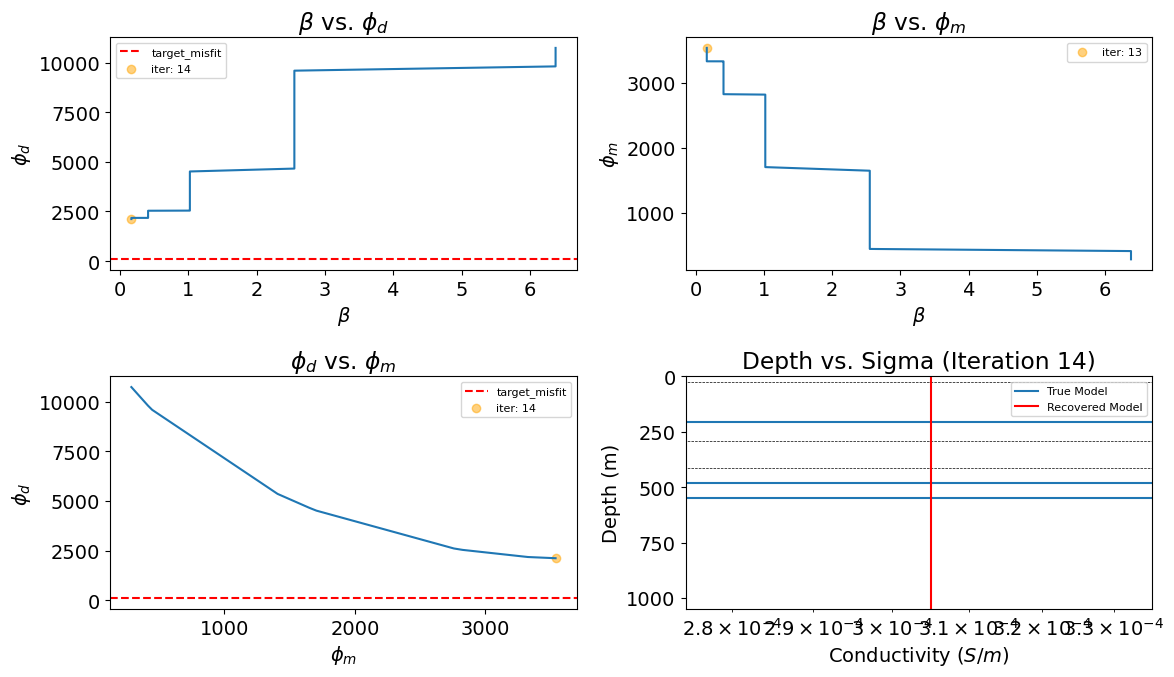

In [14]:
fig, ax = plt.subplots(2,2, figsize = (12,7))

#######################
iteration = 13         # --> Moving the iteration for the inversion
#######################

#Plotting L-cuves!


ax[0][0].plot(betas, phi_ds)
ax[0][0].axhline(target_misfit, c = 'red', linestyle ='--', label = 'target_misfit')
ax[0][0].scatter(betas[iteration], phi_ds[iteration], c = 'orange', alpha = 0.5, label = f"iter: {iteration +1}")
ax[0][0].legend(fontsize = 8)
ax[0][0].set_xlabel(r"$\beta$")
ax[0][0].set_ylabel('$\phi_d$')
ax[0][0].set_title(r'$\beta$ vs. $\phi_d$')


ax[0][1].plot(betas, phi_ms)
ax[0][1].scatter(betas[iteration], phi_ms[iteration], c = 'orange', alpha = 0.5, label = f"iter: {iteration}")
ax[0][1].legend(fontsize = 8)
ax[0][1].set_xlabel(r'$\beta$')
ax[0][1].set_ylabel('$\phi_m$')
ax[0][1].set_title(r'$\beta$ vs. $\phi_m$')



ax[1][0].plot(phi_ms, phi_ds)
ax[1][0].axhline(target_misfit, c = 'red', linestyle ='--', label = 'target_misfit')
ax[1][0].scatter(phi_ms[iteration], phi_ds[iteration], c = 'orange', alpha = 0.5, label = f"iter: {iteration +1}")
ax[1][0].legend(fontsize = 8)
ax[1][0].set_xlabel('$\phi_m$')
ax[1][0].set_ylabel('$\phi_d$')
ax[1][0].set_title('$\phi_d$ vs. $\phi_m$')



#Obtaining the model for the specified iteration
iteration_conductivity_ml = conductivity_halfspace_map * output_dict[iteration + 1]['m'] #* conductivity_halfspace_map



#Plotting True Vs recovered iteration specified
plot_1d_layer_model(layer_thicknesses, sigma, label = 'True Model',ax = ax[1][1], show_layers=True) # figure has base value at log plot
plot_1d_layer_model(layer_thicknesses, 1/rho_hsp_pred*np.ones_like(layer_thicknesses),c = 'r', label = 'Recovered Model', ax = ax[1][1])
ax[1][1].legend(fontsize= 8)
ax[1][1].set_xlabel(r"Conductivity ($S/m$)")
ax[1][1].set_title(f'Depth vs. Sigma (Iteration {iteration + 1})')


plt.tight_layout()

# Moving to a Multi-Layered Inversion using the recovered halfspace results as m0

In [15]:
# Defining Mesh for 7 layers
layer_thick = np.array([25, 180, 85, 125, 65, 70])   #m
rho = np.r_[2000., 2500., 4000., 4500., 8000., 500., 10000.] #ohm-m
n_layers_halfspace = len(rho)


# Defining the mapping
conductivity_halfspace_map = maps.ExpMap(nP=n_layers_halfspace)

m0 = np.log(1/rho_hsp_pred)* np.ones(n_layers_halfspace)

# Reference model, same as starting 
reference_conductivity_model = m0.copy()


simulation_hsp = nsem.simulation_1d.Simulation1DRecursive(
        survey=survey,
        sigma = 1/rho,
        thicknesses=layer_thick,
        sigmaMap=conductivity_halfspace_map
    )

dobs_new = [dpred[:,0] , dpred[:,1], dpred[:,2]*-1 ,  dpred[:,3] * -1 ] # Putting the xy and yx components into a list
dobs_new = np.array(dobs_new) # turning it to a numpy array
dobs_new = dobs_new.flatten(order = 'F') #Flattening it per column instead of per row



### Data Misfit
data_object = data.Data(survey,
                        dobs=dobs_new,
                        relative_error=0.05) # Using relative error instead of uncertainty
dmis_hsp_L2 = data_misfit.L2DataMisfit(simulation=simulation_hsp,
                                       data=data_object)

### Regularization

h = np.r_[layer_thick]

# Create regularization mesh
regularization_mesh_hs = TensorMesh([np.ones(n_layers_halfspace)], "N")

reg_L2 = regularization.WeightedLeastSquares(
        regularization_mesh_hs,
        length_scale_x=10.0,
        reference_model=reference_conductivity_model,
        reference_model_in_smooth=True
        )

#Set regularization parameters:
reg_L2.alpha_s = 10
reg_L2.alpha_x= 1e-4


### Optimization
opt_L2 = optimization.InexactGaussNewton(
    maxIter=50, maxIterLS=20, maxIterCG=20, tolCG=1e-3
)

### Inversion Parameters

inv_prob_L2 = inverse_problem.BaseInvProblem(dmis_hsp_L2, reg_L2, opt_L2)

#Set inversion directives:
update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=5)
beta_schedule = directives.BetaSchedule(coolingFactor=2.5, coolingRate=3)
target_misfit = directives.TargetMisfit(chifact=1.0)
save_L2_hp = directives.SaveOutputDictEveryIteration()

directives_list_L2 = [
    update_jacobi,
    starting_beta,
    beta_schedule,
    target_misfit,
    save_L2_hp
]

### Inversion !!!
# Combine the inverse problem and the set of directives
inv_L2 = inversion.BaseInversion(inv_prob_L2, directives_list_L2)

# Run the inversion
recovered_halfspace_model_L2 = inv_L2.run(m0)

## Get the recovered halfspace resistivity from model estimated
conductivities_ml = conductivity_halfspace_map * recovered_halfspace_model_L2
output_dict = save_L2_hp.outDict



INFO: Directive TargetMisfit: Target data misfit is 92.0



Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  1.13e+03  2.12e+03  0.00e+00  2.12e+03                                 
   1  1.13e+03  1.74e+03  1.50e-01  1.91e+03    3.21e+03      0              
   2  1.13e+03  1.73e+03  1.64e-01  1.91e+03    1.48e+02      0              
   3  1.13e+03  1.73e+03  1.64e-01  1.91e+03    7.18e+00      0              
   4  4.50e+02  1.36e+03  7.05e-01  1.67e+03    1.73e+03      0              
   5  4.50e+02  1.33e+03  7.61e-01  1.67e+03    1.48e+02      0              
   6  4.50e+02  1.33e+03  7.66e-01  1.67e+03    1.26e+01      0              
   7  1.80e+02  8.56e+02  2.41e+00  1.29e+03    1.50e+03      0              
   8  1.80e+02  8.13e+02  2.64e+00  1.29e+03    1.91e+02      0              
   9  1.80e+02  8.07e+02

In [16]:
np.round(1/conductivities_ml[::-1]), 1/sigma

(array([2467., 2891., 2657., 2751., 1616., 3074., 8358.]),
 array([ 2000.,  2500.,  4000.,  4500.,  8000.,   500., 10000.]))

In [17]:
results = {'True':sigma, 'Recovered':conductivities_ml[::-1], 'Delta': sigma - conductivities_ml[::-1]}
results = pd.DataFrame(results)
print('Results in S/m:')
results

Results in S/m:


,True,Recovered,Delta
0,0.000500,0.000405,0.000095
1,0.000400,0.000346,0.000054
2,0.000250,0.000376,-0.000126
3,0.000222,0.000364,-0.000141
4,0.000125,0.000619,-0.000494
5,0.002000,0.000325,0.001675
6,0.000100,0.000120,-0.000020


Text(0.5, 1.0, 'Depth vs. Sigma (Converged Solution)')

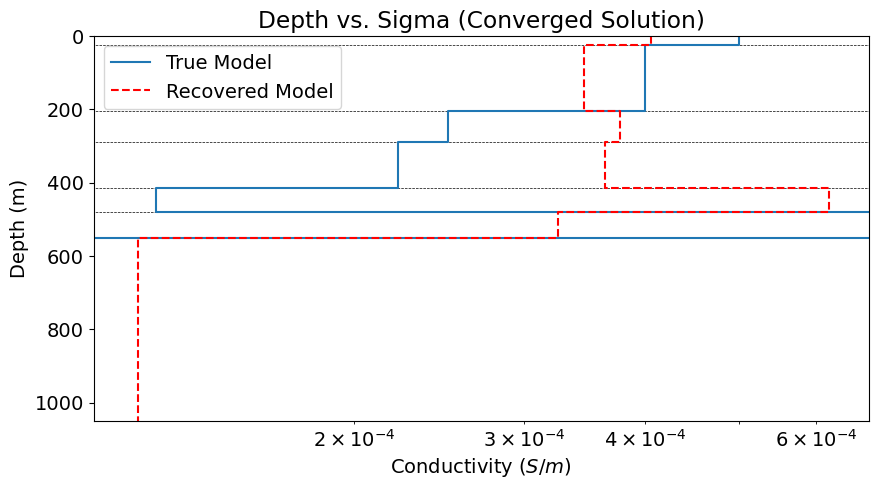

In [18]:
#Plotting True Vs recovered
fig , ax= plt.subplots(1,1,figsize=(10, 5))
plot_1d_layer_model(layer_thicknesses, sigma, label = 'True Model',ax = ax, show_layers=True) # figure has base value at log plot
plot_1d_layer_model(layer_thicknesses, conductivities_ml[::-1],c = 'r', linestyle = '--', label = 'Recovered Model', ax = ax)

ax.legend()
ax.set_xlabel(r"Conductivity ($S/m$)")
ax.set_title('Depth vs. Sigma (Converged Solution)')

### Plotting Tikhonov Curves (L-curves)

In [19]:
target_misfit = dpred.size
iterations = list(output_dict.keys())
n_iteration = len(iterations)
phi_ds = np.zeros(n_iteration)
phi_ms = np.zeros(n_iteration)
betas = np.zeros(n_iteration)
for ii, iteration in enumerate(iterations):
    phi_ds[ii] = output_dict[iteration]['phi_d']
    phi_ms[ii] = output_dict[iteration]['phi_m']
    betas[ii] = output_dict[iteration]['beta']

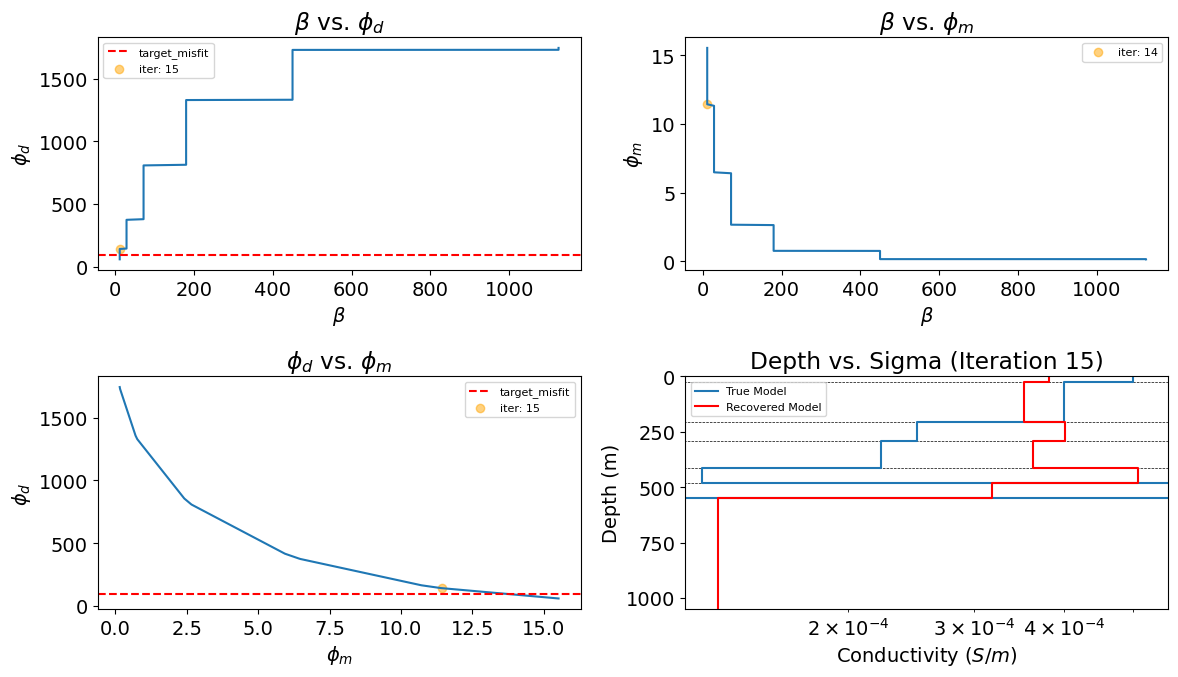

In [20]:
fig, ax = plt.subplots(2,2, figsize = (12,7))

#######################
iteration = 14         # --> Moving the iteration for the inversion
#######################

#Plotting L-cuves!


ax[0][0].plot(betas, phi_ds)
ax[0][0].axhline(target_misfit, c = 'red', linestyle ='--', label = 'target_misfit')
ax[0][0].scatter(betas[iteration], phi_ds[iteration], c = 'orange', alpha = 0.5, label = f"iter: {iteration +1}")
ax[0][0].legend(fontsize = 8)
ax[0][0].set_xlabel(r"$\beta$")
ax[0][0].set_ylabel('$\phi_d$')
ax[0][0].set_title(r'$\beta$ vs. $\phi_d$')


ax[0][1].plot(betas, phi_ms)
ax[0][1].scatter(betas[iteration], phi_ms[iteration], c = 'orange', alpha = 0.5, label = f"iter: {iteration}")
ax[0][1].legend(fontsize = 8)
ax[0][1].set_xlabel(r'$\beta$')
ax[0][1].set_ylabel('$\phi_m$')
ax[0][1].set_title(r'$\beta$ vs. $\phi_m$')



ax[1][0].plot(phi_ms, phi_ds)
ax[1][0].axhline(target_misfit, c = 'red', linestyle ='--', label = 'target_misfit')
ax[1][0].scatter(phi_ms[iteration], phi_ds[iteration], c = 'orange', alpha = 0.5, label = f"iter: {iteration +1}")
ax[1][0].legend(fontsize = 8)
ax[1][0].set_xlabel('$\phi_m$')
ax[1][0].set_ylabel('$\phi_d$')
ax[1][0].set_title('$\phi_d$ vs. $\phi_m$')



#Obtaining the model for the specified iteration
iteration_conductivity_ml = conductivity_halfspace_map * output_dict[iteration + 1]['m'] #* conductivity_halfspace_map



#Plotting True Vs recovered iteration specified
plot_1d_layer_model(layer_thicknesses, sigma, label = 'True Model',ax = ax[1][1], show_layers=True) # figure has base value at log plot
plot_1d_layer_model(layer_thicknesses, iteration_conductivity_ml[::-1],c = 'r', label = 'Recovered Model', ax = ax[1][1])
ax[1][1].legend(fontsize= 8)
ax[1][1].set_xlabel(r"Conductivity ($S/m$)")
ax[1][1].set_title(f'Depth vs. Sigma (Iteration {iteration + 1})')


plt.tight_layout()

### Testing Area (Dangerous!!!):